# CLIP GradCAM Analysis

This notebook provides an interactive way to analyze CLIP models using various CAM methods. You can load the model once and then experiment with different images and target layers.

## Import Required Libraries

In [1]:
import sys
import os
sys.path.append(os.path.join(os.getcwd(), os.pardir))
os.environ['HF_ENDPOINT'] = 'https://hf-mirror.com'
os.environ['CUDA_VISIBLE_DEVICES'] = '2'
os.environ['HOME'] = '/data25/wuqin'
import cv2
import numpy as np
import torch
from torch import nn
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
try:
    from transformers import CLIPProcessor, CLIPModel
except ImportError:
    print("The transformers package is not installed. Please install it to use CLIP.")
    raise

from pytorch_grad_cam import GradCAM, \
    ScoreCAM, \
    GradCAMPlusPlus, \
    AblationCAM, \
    XGradCAM, \
    EigenCAM, \
    EigenGradCAM, \
    LayerCAM, \
    FullGrad

from pytorch_grad_cam.utils.image import show_cam_on_image, \
    preprocess_image
from pytorch_grad_cam.ablation_layer import AblationLayerVit

import matplotlib.pyplot as plt
from IPython.display import Image, display
import os

/data25/wuqin/miniforge3/envs/qwen2_5vl/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Define Helper Functions

In [2]:
def reshape_transform(tensor, height=16, width=16):
    result = tensor[:, 1:, :].reshape(tensor.size(0),
                                      height, width, tensor.size(2))

    # Bring the channels to the first dimension,
    # like in CNNs.
    result = result.transpose(2, 3).transpose(1, 2)
    return result


class ImageClassifier(nn.Module):
    def __init__(self, labels):
        super(ImageClassifier, self).__init__()
        self.clip = CLIPModel.from_pretrained("/data25/wuqin/projects/pytorch-grad-cam/ckpt/clip-vit-large-patch14")
        self.processor = CLIPProcessor.from_pretrained("/data25/wuqin/projects/pytorch-grad-cam/ckpt/clip-vit-large-patch14")
        self.labels = labels

    def forward(self, x):
        text_inputs = self.processor(text=self.labels, return_tensors="pt", padding=True)

        outputs = self.clip(pixel_values=x, input_ids=text_inputs['input_ids'].to(self.clip.device),
                            attention_mask=text_inputs['attention_mask'].to(self.clip.device))

        logits_per_image = outputs.logits_per_image
        probs = logits_per_image.softmax(dim=1)
        # probs = logits_per_image

        for label, prob in zip(self.labels, probs[0]):
            print(f"{label}: {prob:.4f}")
        return probs

## Configuration

Set up device, labels, and other parameters.

In [3]:
# Configuration
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

# Default labels - you can modify these
labels = ["a cat", "a dog", "a car", "a person", "a shoe"]

# CAM methods available
methods = {
    "gradcam": GradCAM,
    "scorecam": ScoreCAM,
    "gradcam++": GradCAMPlusPlus,
    "ablationcam": AblationCAM,
    "xgradcam": XGradCAM,
    "eigencam": EigenCAM,
    "eigengradcam": EigenGradCAM,
    "layercam": LayerCAM,
    "fullgrad": FullGrad
}

print(f"Available methods: {list(methods.keys())}")

Using device: cuda
Available methods: ['gradcam', 'scorecam', 'gradcam++', 'ablationcam', 'xgradcam', 'eigencam', 'eigengradcam', 'layercam', 'fullgrad']


## Load Model (Run Once)

Load the CLIP model. This cell only needs to be run once.

In [4]:
# Load model - this only needs to be run once
model = ImageClassifier(labels).to(torch.device(device)).eval()
print("Model loaded successfully!")
print(f"Model device: {next(model.parameters()).device}")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Model loaded successfully!
Model device: cuda:0


In [6]:
print(model.clip.vision_model)

CLIPVisionTransformer(
  (embeddings): CLIPVisionEmbeddings(
    (patch_embedding): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14), bias=False)
    (position_embedding): Embedding(257, 1024)
  )
  (pre_layrnorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
  (encoder): CLIPEncoder(
    (layers): ModuleList(
      (0-23): 24 x CLIPEncoderLayer(
        (self_attn): CLIPAttention(
          (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
          (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
          (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
          (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
        )
        (layer_norm1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (mlp): CLIPMLP(
          (activation_fn): QuickGELUActivation()
          (fc1): Linear(in_features=1024, out_features=4096, bias=True)
          (fc2): Linear(in_features=4096, out_features=1024, bias

## Define Target Layers

You can easily modify the target layers here for different analysis.

In [30]:
# Define target layers - you can easily modify this
target_layers = [model.clip.vision_model.encoder.layers[-1].layer_norm1]

# Alternative target layers you can try:
# target_layers = [model.clip.vision_model.encoder.layers[-2].layer_norm1]  # Second to last layer
# target_layers = [model.clip.vision_model.encoder.layers[-3].layer_norm1]  # Third to last layer
# target_layers = [model.clip.vision_model.encoder.layers[12].layer_norm1]  # Layer 12

print(f"Target layers: {target_layers}")

Target layers: [LayerNorm((1024,), eps=1e-05, elementwise_affine=True)]


## Load and Preprocess Image

Load your image here. You can easily change the image path to analyze different images.

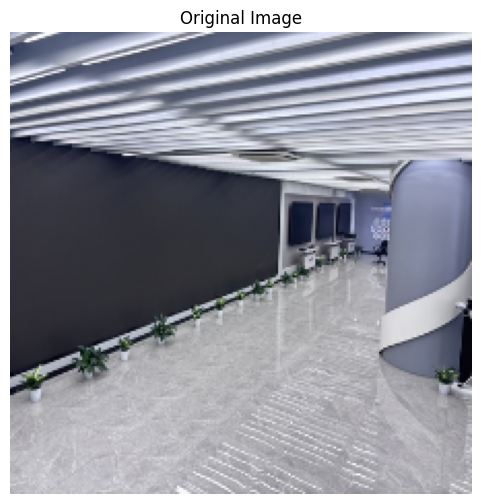

Image loaded: /data25/wuqin/projects/FlagEmbedding/research/visual_bge/vl_query_samples/test6/IMG_1786.jpg
Image shape: (224, 224, 3)
Input tensor shape: torch.Size([1, 3, 224, 224])


In [44]:
# Image path - you can easily modify this
image_path = '/data25/wuqin/projects/FlagEmbedding/research/visual_bge/vl_query_samples/test6/IMG_1786.jpg'

# Load and preprocess image
rgb_img = cv2.imread(image_path, 1)[:, :, ::-1]
rgb_img = cv2.resize(rgb_img, (224, 224))
rgb_img = np.float32(rgb_img) / 255
input_tensor = preprocess_image(rgb_img, mean=[0.5, 0.5, 0.5],
                                std=[0.5, 0.5, 0.5]).to(device)

# Display the original image
plt.figure(figsize=(6, 6))
plt.imshow(rgb_img)
plt.title('Original Image')
plt.axis('off')
plt.show()

print(f"Image loaded: {image_path}")
print(f"Image shape: {rgb_img.shape}")
print(f"Input tensor shape: {input_tensor.shape}")

## Model Prediction

See what the model predicts for the current image and labels.

In [48]:
model.labels = ['pillar', 'background']
# Get model predictions
print("Model predictions:")
with torch.no_grad():
    predictions = model(input_tensor)

print(f"\nPredicted class: {model.labels[predictions.argmax().item()]}")

Model predictions:
pillar: 0.8282
background: 0.1718

Predicted class: pillar


## Generate CAM

Generate and visualize the CAM. You can easily change the method, augmentation settings, and other parameters.

In [49]:
# CAM parameters - you can easily modify these
method = 'gradcam'  # [gradcam, eigencam]
aug_smooth = False  # Set to True for test time augmentation
eigen_smooth = False  # Set to True to reduce noise
targets = [ClassifierOutputTarget(0)]  # None for highest scoring category, or [ClassifierOutputTarget(class_index)]

print(f"Using method: {method}")
print(f"Aug smooth: {aug_smooth}")
print(f"Eigen smooth: {eigen_smooth}")

# Create CAM object
if method == "ablationcam":
    cam = methods[method](model=model,
                         target_layers=target_layers,
                         reshape_transform=reshape_transform,
                         ablation_layer=AblationLayerVit())
else:
    cam = methods[method](model=model,
                         target_layers=target_layers,
                         reshape_transform=reshape_transform)

# Set batch size for faster computation
cam.batch_size = 32

# Generate CAM
grayscale_cam = cam(input_tensor=input_tensor,
                   targets=targets,
                   eigen_smooth=eigen_smooth,
                   aug_smooth=aug_smooth)

# Get the CAM for the first (and only) image in the batch
grayscale_cam = grayscale_cam[0, :]

print("CAM generated successfully!")

Using method: gradcam
Aug smooth: False
Eigen smooth: False
pillar: 0.8282
background: 0.1718
CAM generated successfully!


## Visualize Results

Display the original image and the CAM overlay.

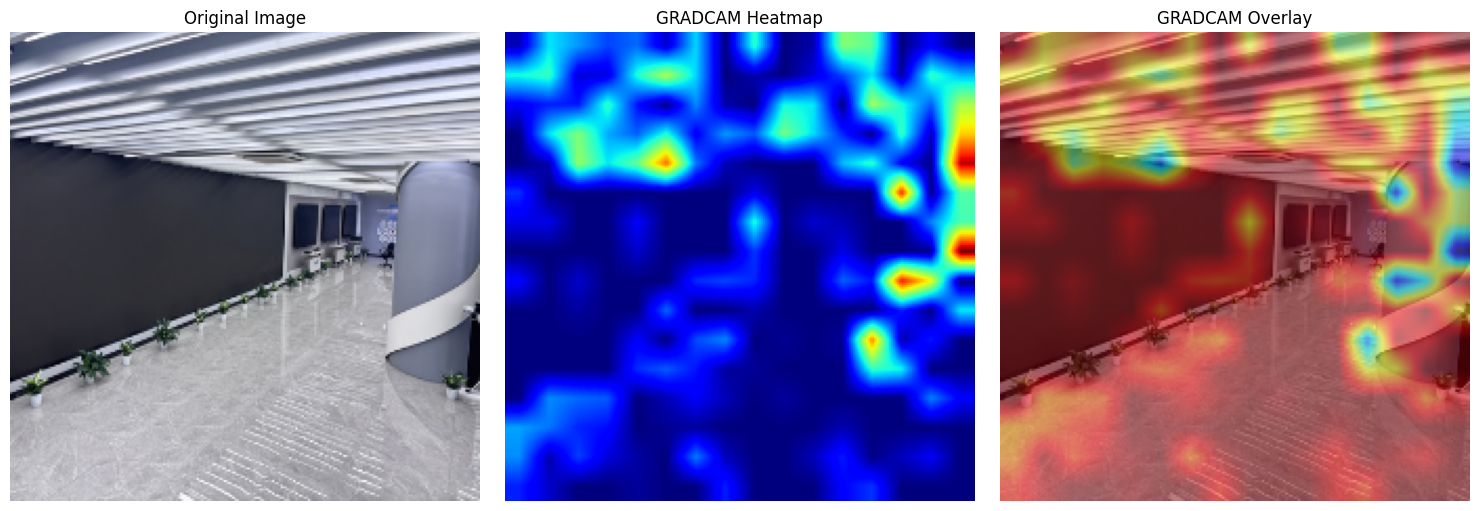

Result saved as: gradcam_cam.jpg


In [50]:
# Create CAM overlay
cam_image = show_cam_on_image(rgb_img, grayscale_cam)

# Display results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original image
axes[0].imshow(rgb_img)
axes[0].set_title('Original Image')
axes[0].axis('off')

# Grayscale CAM
axes[1].imshow(grayscale_cam, cmap='jet')
axes[1].set_title(f'{method.upper()} Heatmap')
axes[1].axis('off')

# CAM overlay
axes[2].imshow(cam_image)
axes[2].set_title(f'{method.upper()} Overlay')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Save the result
output_filename = f'{method}_cam.jpg'
cv2.imwrite(output_filename, cam_image)
print(f"Result saved as: {output_filename}")

## Quick Experiment Cell

Use this cell for quick experiments with different parameters.

In [ ]:
# Quick experiment - modify parameters here and run this cell
experiment_method = 'eigencam'  # Try different methods
experiment_image = '../examples/cat.jpg'  # Try different images

# Load new image if different
if experiment_image != image_path:
    rgb_img_exp = cv2.imread(experiment_image, 1)[:, :, ::-1]
    rgb_img_exp = cv2.resize(rgb_img_exp, (224, 224))
    rgb_img_exp = np.float32(rgb_img_exp) / 255
    input_tensor_exp = preprocess_image(rgb_img_exp, mean=[0.5, 0.5, 0.5],
                                       std=[0.5, 0.5, 0.5]).to(device)
else:
    rgb_img_exp = rgb_img
    input_tensor_exp = input_tensor

# Create new CAM
if experiment_method == "ablationcam":
    cam_exp = methods[experiment_method](model=model,
                                        target_layers=target_layers,
                                        reshape_transform=reshape_transform,
                                        ablation_layer=AblationLayerVit())
else:
    cam_exp = methods[experiment_method](model=model,
                                        target_layers=target_layers,
                                        reshape_transform=reshape_transform)

cam_exp.batch_size = 32

# Generate and display
grayscale_cam_exp = cam_exp(input_tensor=input_tensor_exp, targets=None)
grayscale_cam_exp = grayscale_cam_exp[0, :]
cam_image_exp = show_cam_on_image(rgb_img_exp, grayscale_cam_exp)

# Display
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(rgb_img_exp)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(cam_image_exp)
axes[1].set_title(f'{experiment_method.upper()} Result')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f"Experiment completed with method: {experiment_method}")

## Layer Analysis

Compare CAMs from different layers.

In [ ]:
# Compare different layers
layer_indices = [-1, -2, -3, -4]  # Last 4 layers
method_for_comparison = 'gradcam'

fig, axes = plt.subplots(2, len(layer_indices), figsize=(20, 10))

for i, layer_idx in enumerate(layer_indices):
    # Define target layer
    target_layer = [model.clip.vision_model.encoder.layers[layer_idx].layer_norm1]

    # Create CAM
    cam_layer = methods[method_for_comparison](model=model,
                                              target_layers=target_layer,
                                              reshape_transform=reshape_transform)

    # Generate CAM
    grayscale_cam_layer = cam_layer(input_tensor=input_tensor, targets=None)
    grayscale_cam_layer = grayscale_cam_layer[0, :]
    cam_image_layer = show_cam_on_image(rgb_img, grayscale_cam_layer)

    # Display heatmap
    axes[0, i].imshow(grayscale_cam_layer, cmap='jet')
    axes[0, i].set_title(f'Layer {layer_idx} Heatmap')
    axes[0, i].axis('off')

    # Display overlay
    axes[1, i].imshow(cam_image_layer)
    axes[1, i].set_title(f'Layer {layer_idx} Overlay')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

print("Layer comparison completed!")

## Method Comparison

Compare different CAM methods on the same image.

In [ ]:
# Compare different methods
methods_to_compare = ['gradcam', 'eigencam', 'gradcam++', 'scorecam']

fig, axes = plt.subplots(2, len(methods_to_compare), figsize=(20, 10))

for i, method_name in enumerate(methods_to_compare):
    print(f"Processing {method_name}...")

    # Create CAM
    if method_name == "ablationcam":
        cam_method = methods[method_name](model=model,
                                         target_layers=target_layers,
                                         reshape_transform=reshape_transform,
                                         ablation_layer=AblationLayerVit())
    else:
        cam_method = methods[method_name](model=model,
                                         target_layers=target_layers,
                                         reshape_transform=reshape_transform)

    cam_method.batch_size = 32

    # Generate CAM
    grayscale_cam_method = cam_method(input_tensor=input_tensor, targets=None)
    grayscale_cam_method = grayscale_cam_method[0, :]
    cam_image_method = show_cam_on_image(rgb_img, grayscale_cam_method)

    # Display heatmap
    axes[0, i].imshow(grayscale_cam_method, cmap='jet')
    axes[0, i].set_title(f'{method_name.upper()} Heatmap')
    axes[0, i].axis('off')

    # Display overlay
    axes[1, i].imshow(cam_image_method)
    axes[1, i].set_title(f'{method_name.upper()} Overlay')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

print("Method comparison completed!")